In [1]:
import boto3
import pandas as pd
import time
import io

# Query Athena and return results as a pandas DataFrame
def query_athena(query, database='fx_rates_db', region='us-east-2'):
    athena = boto3.client('athena', region_name=region)
    s3 = boto3.client('s3', region_name=region)
    
    output_location = 's3://fx-rates-ninpar/athena-results/'
    
    response = athena.start_query_execution(
        QueryString=query,
        QueryExecutionContext={'Database': database},
        ResultConfiguration={'OutputLocation': output_location}
    )
    query_id = response['QueryExecutionId']
    
    # Wait for query to complete
    while True:
        status = athena.get_query_execution(QueryExecutionId=query_id)
        state = status['QueryExecution']['Status']['State']
        if state in ['SUCCEEDED', 'FAILED', 'CANCELLED']:
            break
        time.sleep(1)
    
    if state != 'SUCCEEDED':
        raise Exception(f"Query failed: {status['QueryExecution']['Status'].get('StateChangeReason')}")
    
    # Get the result file from S3
    result_location = status['QueryExecution']['ResultConfiguration']['OutputLocation']
    bucket = result_location.split('/')[2]
    key = '/'.join(result_location.split('/')[3:])
    
    obj = s3.get_object(Bucket=bucket, Key=key)
    df = pd.read_csv(io.BytesIO(obj['Body'].read()))
    
    return df

print("Athena query function ready")

Athena query function ready


In [14]:
df = query_athena("""
    SELECT date, 
           rates.inr AS usd_inr, 
           rates.eur AS usd_eur, 
           rates.gbp AS usd_gbp,
           rates.mxn AS usd_mxn,
           rates.php AS usd_php
    FROM fx_rates_db.usd
    ORDER BY date ASC
""")

df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date').sort_index()

print(f"Loaded {len(df)} trading days")
print(f"Date range: {df.index.min()} to {df.index.max()}")
print(f"\nLatest rates:")
print(df.head())

Loaded 280 trading days
Date range: 2025-04-29 00:00:00 to 2026-06-03 00:00:00

Latest rates:
            usd_inr  usd_eur  usd_gbp  usd_mxn  usd_php
date                                                   
2025-04-29    85.13  0.87928  0.74721      NaN      NaN
2025-04-30    84.53  0.87928  0.74897  19.5217   55.867
2025-05-02    84.30  0.88160  0.75227  19.6879   55.549
2025-05-05    84.30  0.88160  0.75068  19.5874   55.641
2025-05-06    84.38  0.88300  0.74781  19.7139   55.659


In [3]:
import numpy as np

returns = df.pct_change().dropna()

comparison = pd.DataFrame({
    'avg_daily_return': returns.mean(),
    'daily_volatility': returns.std(),
    'annualized_vol': returns.std() * np.sqrt(252),
    'signal_to_noise': returns.mean().abs() / returns.std(),
    'sharpe_annual': (returns.mean() / returns.std()) * np.sqrt(252),
    'trend_direction': ['depreciation' if r > 0 else 'appreciation' 
                        for r in returns.mean()]
})

print("=== Currency Pair Comparison ===\n")
print(comparison.round(6).to_string())

print("\nInterpretation:")
print("Higher |Sharpe| = stronger trend relative to noise = potentially more forecastable")
print("Higher volatility = wider Bollinger bands = more room for signals")

=== Currency Pair Comparison ===

         avg_daily_return  daily_volatility  annualized_vol  signal_to_noise  sharpe_annual trend_direction
usd_inr          0.000437          0.003229        0.051266         0.135346       2.148555    depreciation
usd_eur         -0.000079          0.004011        0.063668         0.019589      -0.310963    appreciation
usd_gbp         -0.000024          0.004252        0.067498         0.005532      -0.087824    appreciation
usd_mxn         -0.000428          0.004900        0.077787         0.087274      -1.385433    appreciation
usd_php          0.000365          0.004098        0.065055         0.089028       1.413269    depreciation

Interpretation:
Higher |Sharpe| = stronger trend relative to noise = potentially more forecastable
Higher volatility = wider Bollinger bands = more room for signals


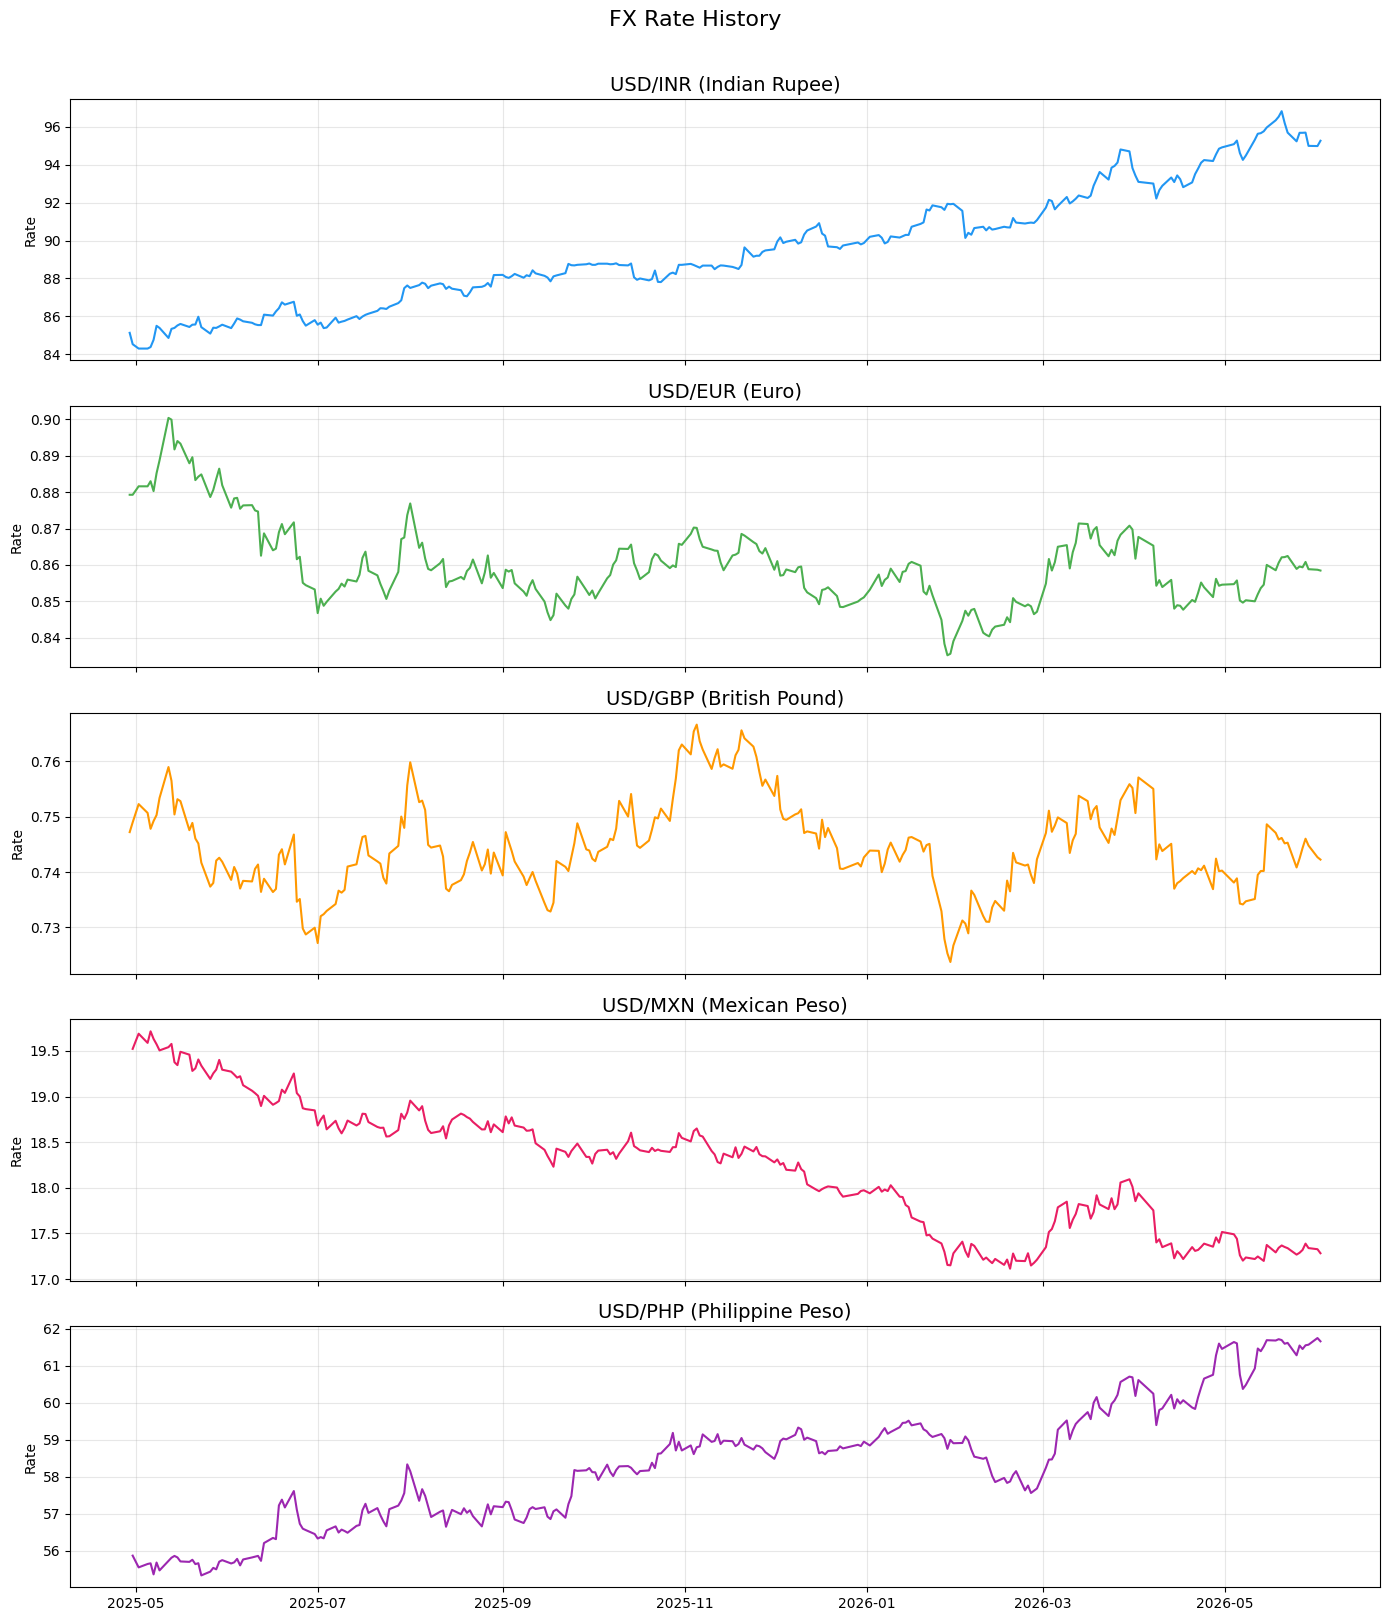

In [10]:
import matplotlib.pyplot as plt

currencies = {
    'usd_inr': ('#2196F3', 'USD/INR (Indian Rupee)'),
    'usd_eur': ('#4CAF50', 'USD/EUR (Euro)'),
    'usd_gbp': ('#FF9800', 'USD/GBP (British Pound)'),
    'usd_mxn': ('#E91E63', 'USD/MXN (Mexican Peso)'),
    'usd_php': ('#9C27B0', 'USD/PHP (Philippine Peso)')
}

fig, axes = plt.subplots(len(currencies), 1, figsize=(14, 16), sharex=True)

for i, (col, (color, title)) in enumerate(currencies.items()):
    axes[i].plot(df.index, df[col], color=color, linewidth=1.5)
    axes[i].set_title(title, fontsize=14)
    axes[i].set_ylabel('Rate')
    axes[i].grid(True, alpha=0.3)

plt.suptitle('FX Rate History', fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig('fx_rate_history.png', dpi=150, bbox_inches='tight')
plt.show()

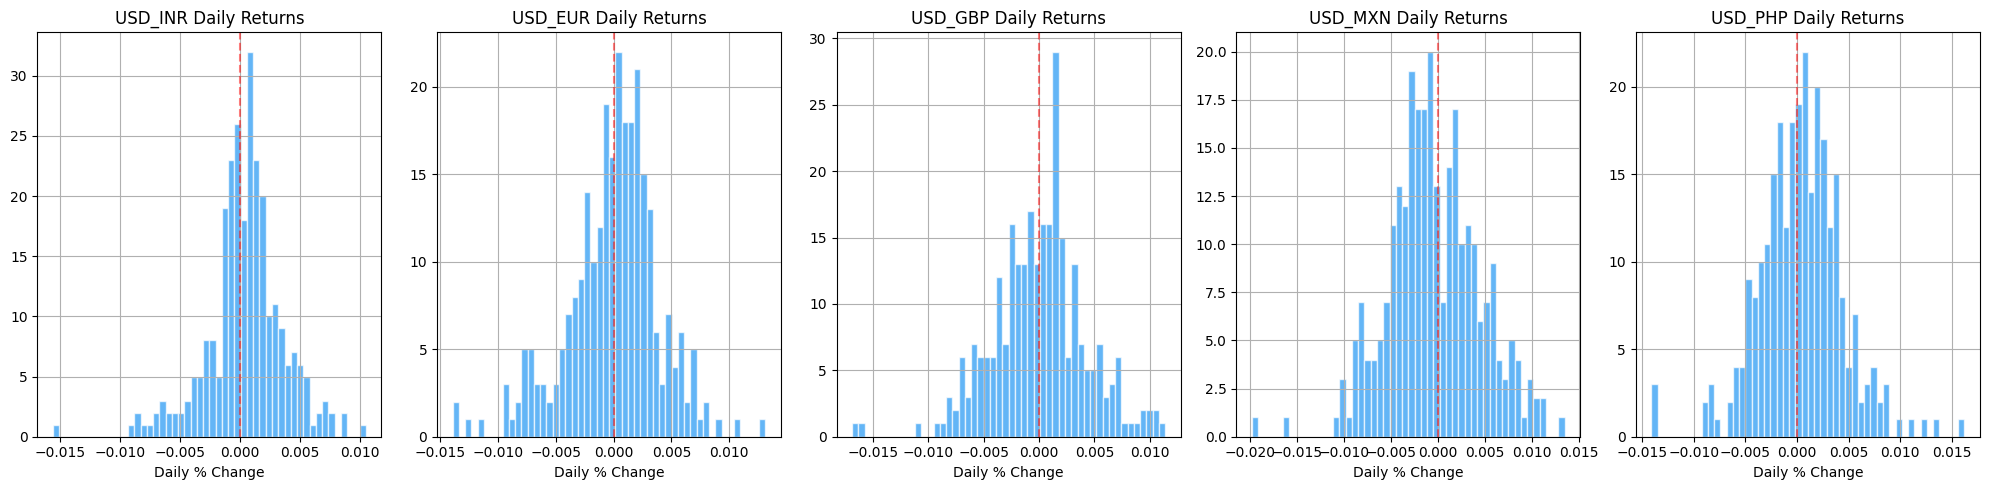

If the distribution is centered near zero and roughly symmetric,
that's consistent with near-random-walk behavior — hard to predict direction.


In [7]:
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for i, col in enumerate(['usd_inr', 'usd_eur', 'usd_gbp','usd_mxn','usd_php']):
    returns[col].hist(bins=50, ax=axes[i], color='#2196F3', alpha=0.7, edgecolor='white')
    axes[i].axvline(0, color='red', linestyle='--', alpha=0.5)
    axes[i].set_title(f'{col.upper()} Daily Returns')
    axes[i].set_xlabel('Daily % Change')

plt.tight_layout()
plt.savefig('fx_returns_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("If the distribution is centered near zero and roughly symmetric,")
print("that's consistent with near-random-walk behavior — hard to predict direction.")

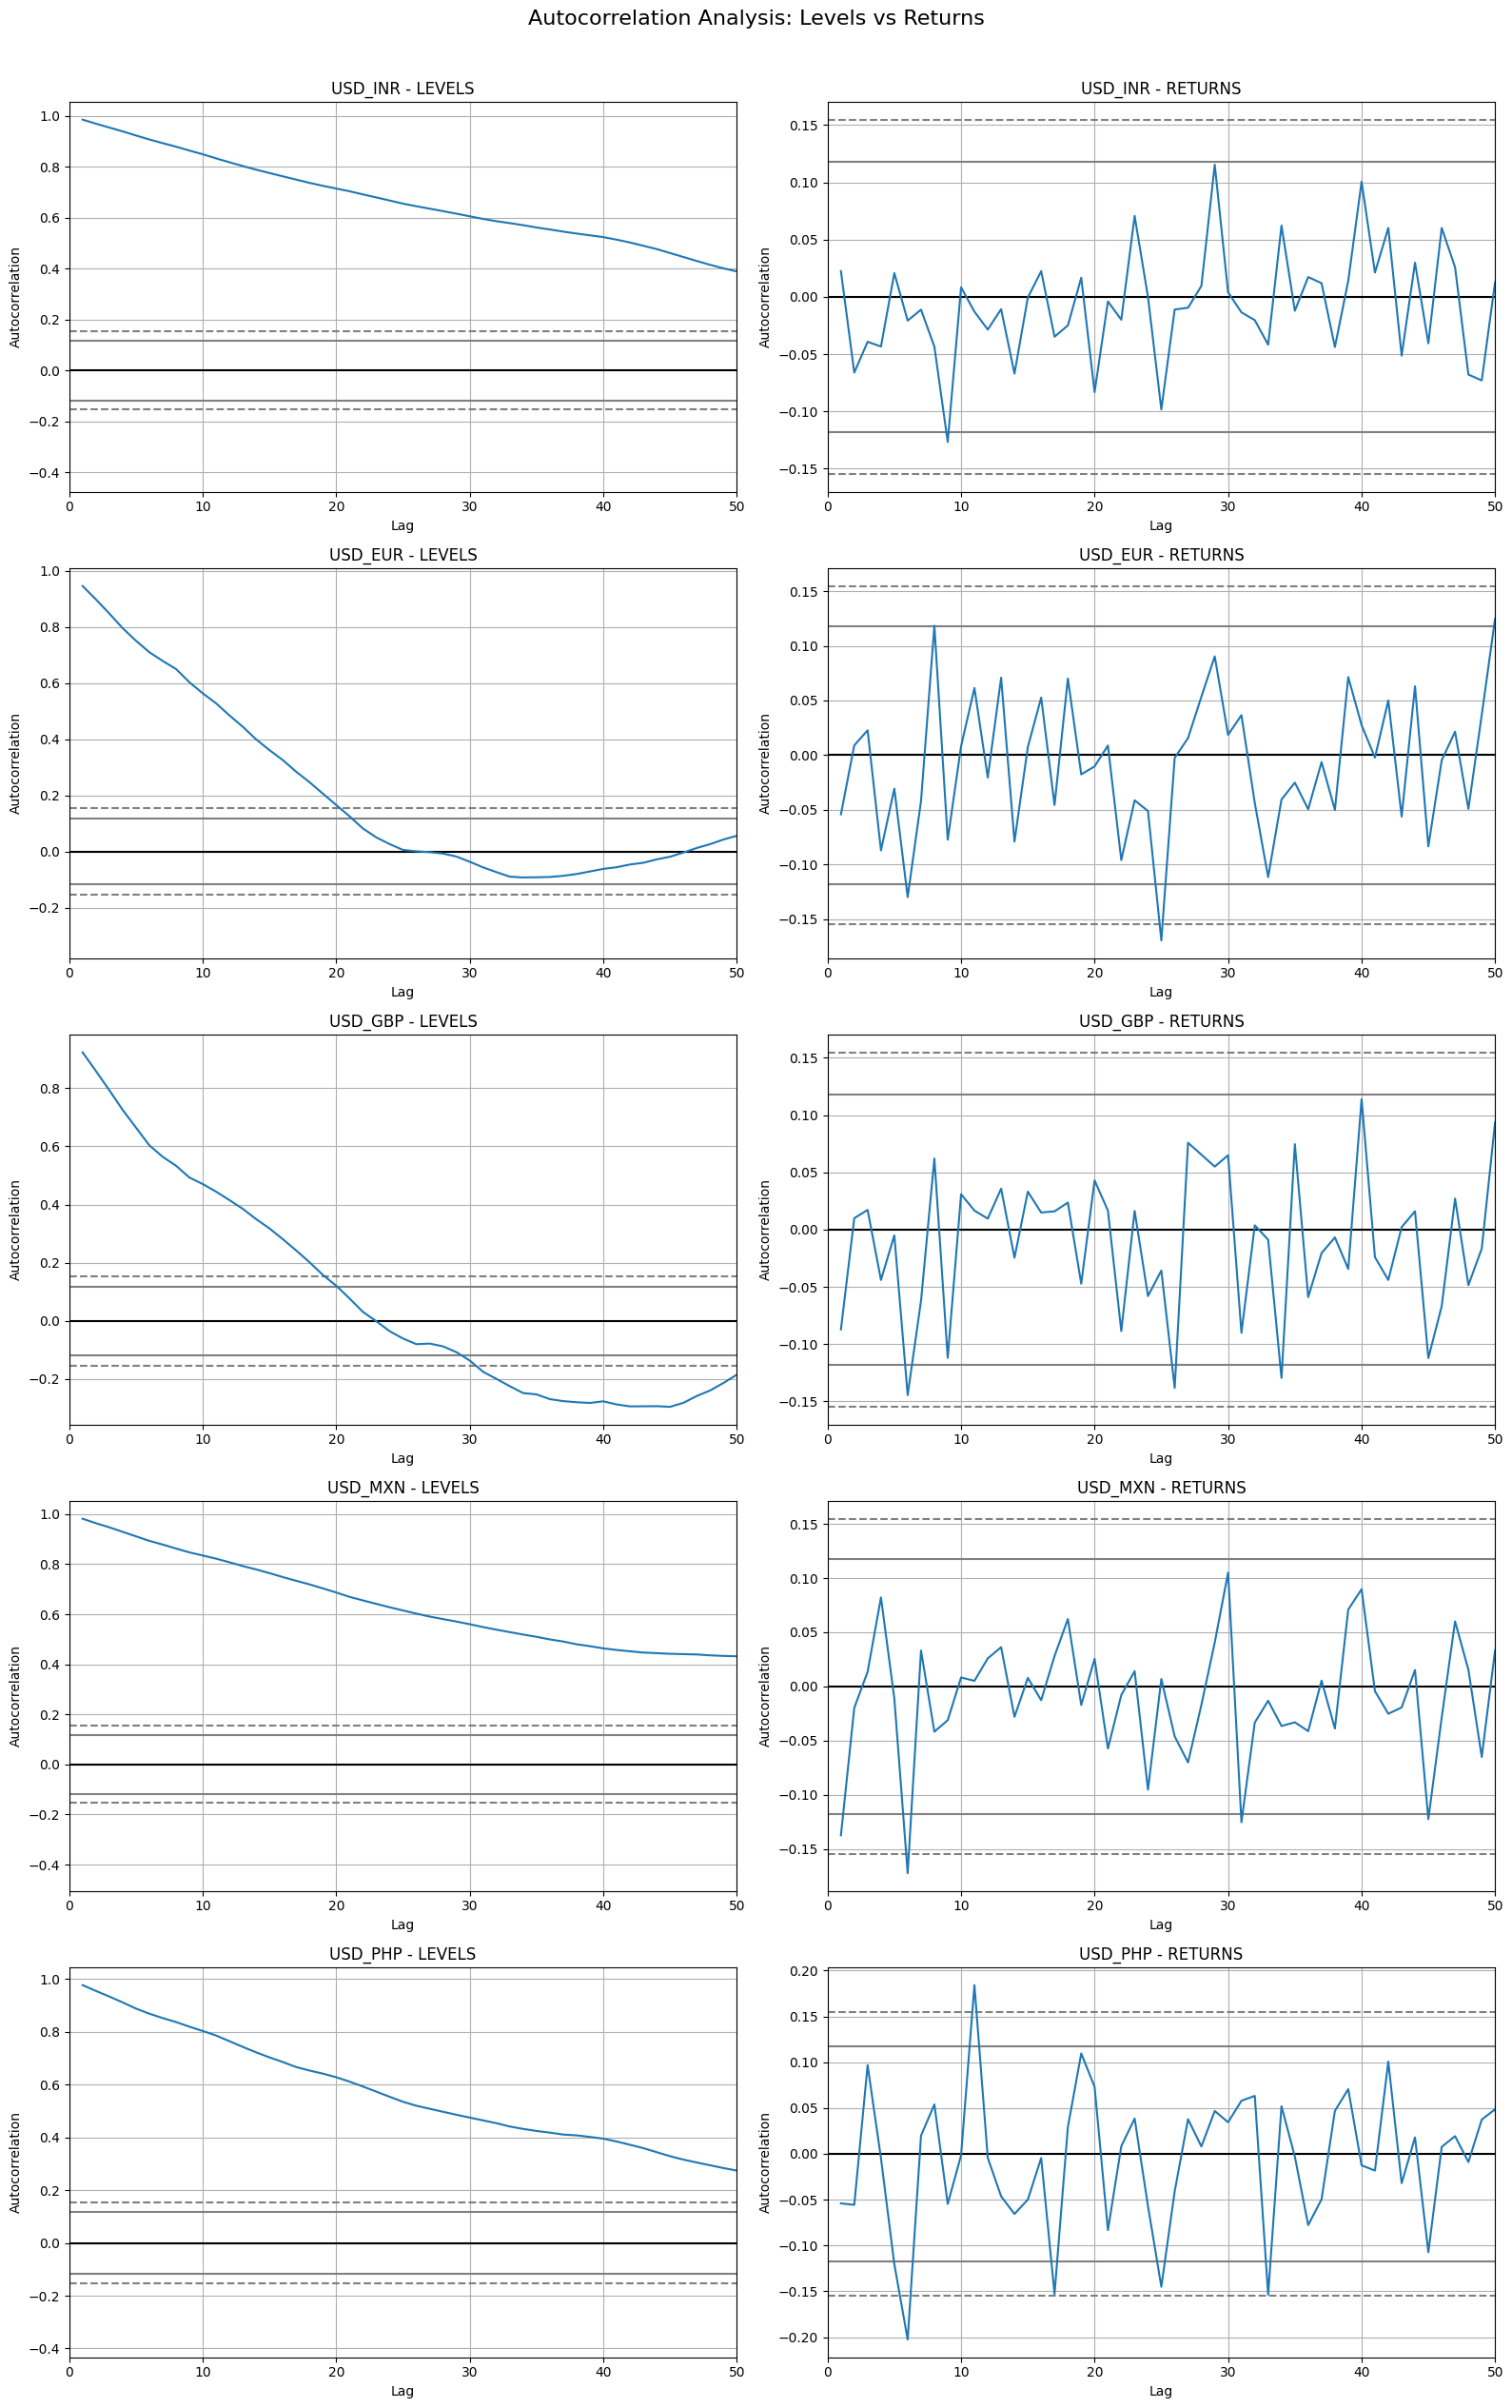

Left column: levels (always high — just confirms trending)
Right column: returns (the forecastability test)

Bars OUTSIDE dashed bands = statistically significant autocorrelation
Bars INSIDE dashed bands = no predictable pattern at that lag


In [16]:
from pandas.plotting import autocorrelation_plot

fig, axes = plt.subplots(5, 2, figsize=(16, 25))

currencies = ['usd_inr', 'usd_eur', 'usd_gbp', 'usd_mxn', 'usd_php']

for i, col in enumerate(currencies):
    # Left: levels
    pd.plotting.autocorrelation_plot(df[col].dropna(), ax=axes[i][0])
    axes[i][0].set_title(f'{col.upper()} - LEVELS', fontsize=12)
    axes[i][0].set_xlim(0, 50)
    
    # Right: returns
    pd.plotting.autocorrelation_plot(returns[col], ax=axes[i][1])
    axes[i][1].set_title(f'{col.upper()} - RETURNS', fontsize=12)
    axes[i][1].set_xlim(0, 50)

plt.suptitle('Autocorrelation Analysis: Levels vs Returns', fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig('fx_autocorrelation_all.png', dpi=150, bbox_inches='tight')
plt.show()

print("Left column: levels (always high — just confirms trending)")
print("Right column: returns (the forecastability test)")
print("\nBars OUTSIDE dashed bands = statistically significant autocorrelation")
print("Bars INSIDE dashed bands = no predictable pattern at that lag")

In [18]:
print("=== Naive Random Walk Baseline ===")
print("Forecast rule: tomorrow's rate = today's rate\n")

baseline_results = {}

for col in ['usd_inr', 'usd_eur', 'usd_gbp', 'usd_mxn', 'usd_php']:
    series = df[col].dropna()
    actual = series.iloc[1:]
    naive = series.shift(1).iloc[1:]
    errors = actual - naive
    
    mae = errors.abs().mean()
    rmse = (errors**2).mean()**0.5
    mape = (errors.abs() / actual).mean() * 100
    
    baseline_results[col] = {'MAE': mae, 'RMSE': rmse, 'MAPE': mape}
    
    print(f"{col.upper()}:")
    print(f"  MAE:  {mae:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  MAPE: {mape:.4f}%")
    print()

# Summary comparison table
baseline_df = pd.DataFrame(baseline_results).T
baseline_df.index = baseline_df.index.str.upper()
print("=== Summary ===\n")
print(baseline_df.round(4).to_string())

print("\n=== What these numbers mean ===")
print(f"USD/INR MAPE of {baseline_results['usd_inr']['MAPE']:.4f}% means:")
print(f"  On a rate of ~90, the naive forecast is off by ~{90 * baseline_results['usd_inr']['MAPE']/100:.2f} on average")
print(f"  Any ML model must beat MAE of {baseline_results['usd_inr']['MAE']:.4f} to be worth using")

=== Naive Random Walk Baseline ===
Forecast rule: tomorrow's rate = today's rate

USD_INR:
  MAE:  0.2134
  RMSE: 0.2966
  MAPE: 0.2370%

USD_EUR:
  MAE:  0.0026
  RMSE: 0.0035
  MAPE: 0.2981%

USD_GBP:
  MAE:  0.0024
  RMSE: 0.0032
  MAPE: 0.3238%

USD_MXN:
  MAE:  0.0705
  RMSE: 0.0892
  MAPE: 0.3871%

USD_PHP:
  MAE:  0.1803
  RMSE: 0.2397
  MAPE: 0.3086%

=== Summary ===

            MAE    RMSE    MAPE
USD_INR  0.2134  0.2966  0.2370
USD_EUR  0.0026  0.0035  0.2981
USD_GBP  0.0024  0.0032  0.3238
USD_MXN  0.0705  0.0892  0.3871
USD_PHP  0.1803  0.2397  0.3086

=== What these numbers mean ===
USD/INR MAPE of 0.2370% means:
  On a rate of ~90, the naive forecast is off by ~0.21 on average
  Any ML model must beat MAE of 0.2134 to be worth using


In [20]:
# Save baseline results for model comparison later
import json

baseline_output = {}
for col in ['usd_inr', 'usd_eur', 'usd_gbp', 'usd_mxn', 'usd_php']:
    series = df[col].dropna()
    actual = series.iloc[1:]
    naive = series.shift(1).iloc[1:]
    errors = actual - naive
    
    # Direction accuracy of naive (predicts no change = 50% baseline)
    actual_direction = (actual.values - naive.values) > 0
    
    baseline_output[col] = {
        'mae': float(errors.abs().mean()),
        'rmse': float((errors**2).mean()**0.5),
        'mape': float((errors.abs() / actual).mean() * 100),
        'direction_accuracy': 0.50,  # naive predicts no change
        'daily_volatility': float(returns[col].std()),
        'sharpe': float((returns[col].mean() / returns[col].std()) * np.sqrt(252))
    }

# Save to file for comparison in later notebooks
with open('baseline_results.json', 'w') as f:
    json.dump(baseline_output, f, indent=2)

print("Baseline saved to notebooks/baseline_results.json")
print("\n=== The bars to beat ===\n")
for pair, metrics in baseline_output.items():
    print(f"{pair.upper()}:")
    print(f"  MAPE < {metrics['mape']:.4f}%  OR  Direction accuracy > 50%")
    print(f"  Sharpe: {metrics['sharpe']:.2f} ({'strong trend' if abs(metrics['sharpe']) > 1 else 'weak/no trend'})")
    print()

Baseline saved to notebooks/baseline_results.json

=== The bars to beat ===

USD_INR:
  MAPE < 0.2370%  OR  Direction accuracy > 50%
  Sharpe: 2.15 (strong trend)

USD_EUR:
  MAPE < 0.2981%  OR  Direction accuracy > 50%
  Sharpe: -0.31 (weak/no trend)

USD_GBP:
  MAPE < 0.3238%  OR  Direction accuracy > 50%
  Sharpe: -0.09 (weak/no trend)

USD_MXN:
  MAPE < 0.3871%  OR  Direction accuracy > 50%
  Sharpe: -1.39 (strong trend)

USD_PHP:
  MAPE < 0.3086%  OR  Direction accuracy > 50%
  Sharpe: 1.41 (strong trend)

